# Chapter 5: Customer Segmentation with K-Means

  ## The Story

  We now know which customers are likely to churn. But "at-risk customer"
  is too broad to act on. A customer who spent £5,000 and bought 30 times
  needs a very different retention offer than one who bought once for £20.

  Segmentation answers: **"Who exactly are our customers?"**

  K-Means clustering groups customers by behavioral similarity — no labels,
  no guessing. The algorithm finds natural groupings in the data. We then
  profile each group and give it a business-readable name like "Champions"
  or "At-Risk" so marketing knows exactly who they're targeting.

  ## Why K-Means?
  K-Means is the industry standard for customer segmentation because:
  - It's fast and scales to millions of customers
  - Results are interpretable — each customer belongs to exactly one group
  - It pairs perfectly with RFM — the features we already built

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
print('Libraries loaded.')

Libraries loaded.


## Step 1 — Load Data and Select Clustering Features

  We load rfm_with_churn.csv — the enriched table we built in Chapters 3 and 4.

  For clustering we use 4 core behavioral features:
  - Recency: how recently they bought
  - Frequency: how often they bought
  - LogMonetary: how much they spent (log-scaled)
  - PurchaseSpread: how long they've been a customer

  We exclude Churn, Q1/Q2/Q3_Orders, and derived flags — these add noise
  to clustering. The goal is to find natural behavioral groups, not
  to predict churn again.

In [3]:
rfm = pd.read_csv('../data/rfm.csv')

print('Shape:', rfm.shape)
print('Columns:', rfm.columns.tolist())
cluster_features = ['Recency', 'Frequency', 'LogMonetary', 'PurchaseSpread']
X = rfm[cluster_features].copy()
print('\nClustering on:', cluster_features)
print(X.describe().round(2))

Shape: (3604, 17)
Columns: ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Churn', 'Q1_Orders', 'Q2_Orders', 'Q3_Orders', 'PurchaseTrend', 'ActiveInQ3', 'AvgOrderValue', 'PurchaseSpread', 'UniqueProducts', 'LogMonetary', 'LogAvgOrderValue', 'IsOneTimeBuyer', 'AvgDaysBetweenPurchases']

Clustering on: ['Recency', 'Frequency', 'LogMonetary', 'PurchaseSpread']
       Recency  Frequency  LogMonetary  PurchaseSpread
count  3604.00    3604.00      3604.00         3604.00
mean     93.02       3.63         6.47           97.05
std      86.56       6.08         1.22          104.01
min       1.00       1.00         1.36            0.00
25%      19.00       1.00         5.65            0.00
50%      64.00       2.00         6.40           63.00
75%     148.00       4.00         7.27          190.00
max     303.00     137.00        12.22          302.00


## Step 2 — Scale Features
 K-Means works by measuring distance between customers.
 Without scaling, Monetary (range: £3–£200K) would completely overpower
 Recency (range: 1–303 days) — the algorithm would only cluster by spending.
 StandardScaler transforms each feature to mean=0, std=1.
 Now all features contribute equally to the distance calculation.

In [4]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('Scaling complete.')
print('Mean after scaling (should be ~0):', X_scaled.mean(axis=0).round(3))
print('Std after scaling  (should be ~1):', X_scaled.std(axis=0).round(3))

Scaling complete.
Mean after scaling (should be ~0): [ 0. -0.  0. -0.]
Std after scaling  (should be ~1): [1. 1. 1. 1.]


## Step 3 — Find the Optimal Number of Clusters

  How many segments should we create? We use two methods:

  **Elbow Method:** Plot inertia (total within-cluster distance) for K=2 to K=10.
  The "elbow" — where the curve bends and flattening begins — is the optimal K.
  Beyond that point, adding more clusters gives diminishing returns.

  **Silhouette Score:** Measures how well each customer fits its assigned cluster
  vs the nearest other cluster. Score ranges from -1 to 1 — higher is better.
  The K with the highest silhouette score is the most well-separated clustering.

  We use both together — the right answer satisfies both criteria.

In [5]:
inertias    = []
silhouettes = []
K_range     = range(2, 11)
for k in K_range:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))
    print(f'K={k}  | Inertia: {km.inertia_:,.0f}  | Silhouette: {silhouette_score(X_scaled, km.labels_):.4f}')

K=2  | Inertia: 8,201  | Silhouette: 0.4249
K=3  | Inertia: 6,365  | Silhouette: 0.3511
K=4  | Inertia: 4,698  | Silhouette: 0.3703
K=5  | Inertia: 3,851  | Silhouette: 0.3419
K=6  | Inertia: 3,305  | Silhouette: 0.3345
K=7  | Inertia: 2,937  | Silhouette: 0.3215
K=8  | Inertia: 2,613  | Silhouette: 0.3117
K=9  | Inertia: 2,386  | Silhouette: 0.3033
K=10  | Inertia: 2,189  | Silhouette: 0.2997


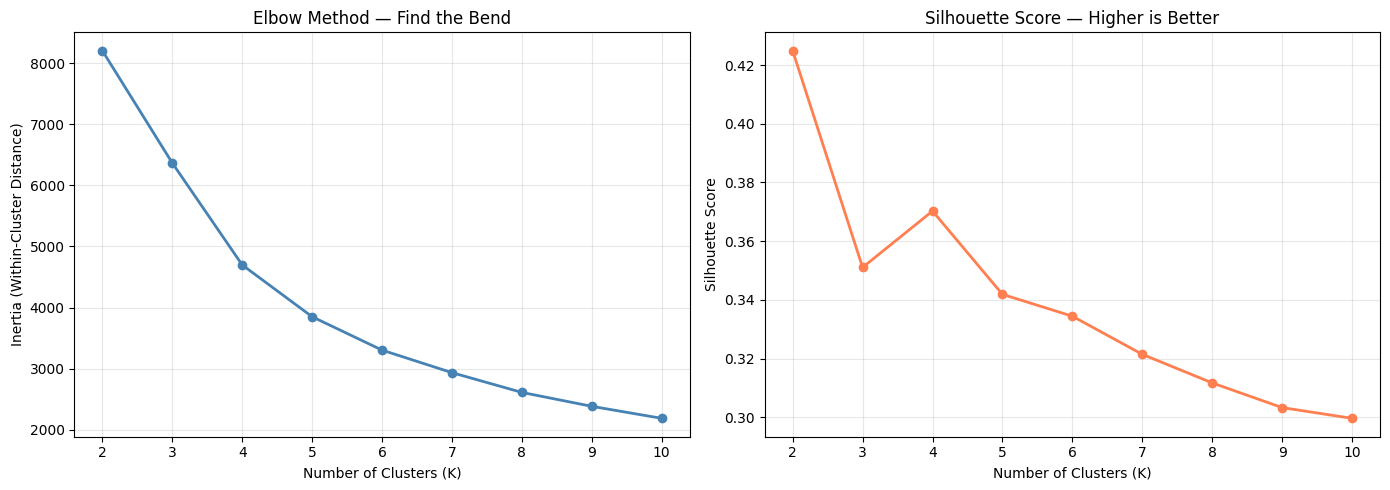

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Elbow Method — Find the Bend')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (Within-Cluster Distance)')
axes[0].grid(alpha=0.3)
axes[1].plot(K_range, silhouettes, marker='o', color='coral', linewidth=2)
axes[1].set_title('Silhouette Score — Higher is Better')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../data/elbow_silhouette.png', dpi=150)
plt.show()

## Step 4 — Fit K-Means with K=4
K=2 scored highest on silhouette but gives only two groups — too broad
for meaningful business action. K=4 is the next peak (0.37 silhouette)
and corresponds to the elbow bend — the best balance between
mathematical fit and business interpretability.
Four segments is the retail industry standard: it maps naturally to
Champions, Loyal, At-Risk, and Lost customers.

In [7]:
K_OPTIMAL = 4

km_final = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
rfm['Segment'] = km_final.fit_predict(X_scaled)
print(f'K-Means fitted with K={K_OPTIMAL}')
print('\nCustomers per segment:')
print(rfm['Segment'].value_counts().sort_index())


K-Means fitted with K=4

Customers per segment:
Segment
0    1223
1     958
2      28
3    1395
Name: count, dtype: int64



## Step 5 — Profile Each Segment

Numbers alone don't tell us who these customers are.
We compute the average RFM values per segment to understand
the behavioral fingerprint of each group — then give each
a business-readable name.

In [8]:
profile = rfm.groupby('Segment').agg(
      Customers      = ('CustomerID',    'count'),
      Avg_Recency    = ('Recency',       'mean'),
      Avg_Frequency  = ('Frequency',     'mean'),
      Avg_Monetary   = ('Monetary',      'mean'),
      Avg_Spread     = ('PurchaseSpread','mean'),
      Churn_Rate     = ('Churn',         'mean')
  ).round(2)

print(profile.to_string())


         Customers  Avg_Recency  Avg_Frequency  Avg_Monetary  Avg_Spread  Churn_Rate
Segment                                                                             
0             1223        32.92           6.45       2998.09      219.06        0.26
1              958       214.97           1.25        351.96        8.64        0.72
2               28        17.96          52.32      46590.01      280.07        0.04
3             1395        63.46           1.83        604.79       47.13        0.55


In [12]:
# Map segment numbers to names based on profile output
# Adjust this mapping after seeing the profile above
segment_names = {
      2: 'Champions',
      0: 'Loyal',
      3: 'At-Risk',
      1: 'Lost'
  }
rfm['SegmentName'] = rfm['Segment'].map(segment_names)

print('Segment distribution:')
print(rfm['SegmentName'].value_counts())

Segment distribution:
SegmentName
At-Risk      1395
Loyal        1223
Lost          958
Champions      28
Name: count, dtype: int64


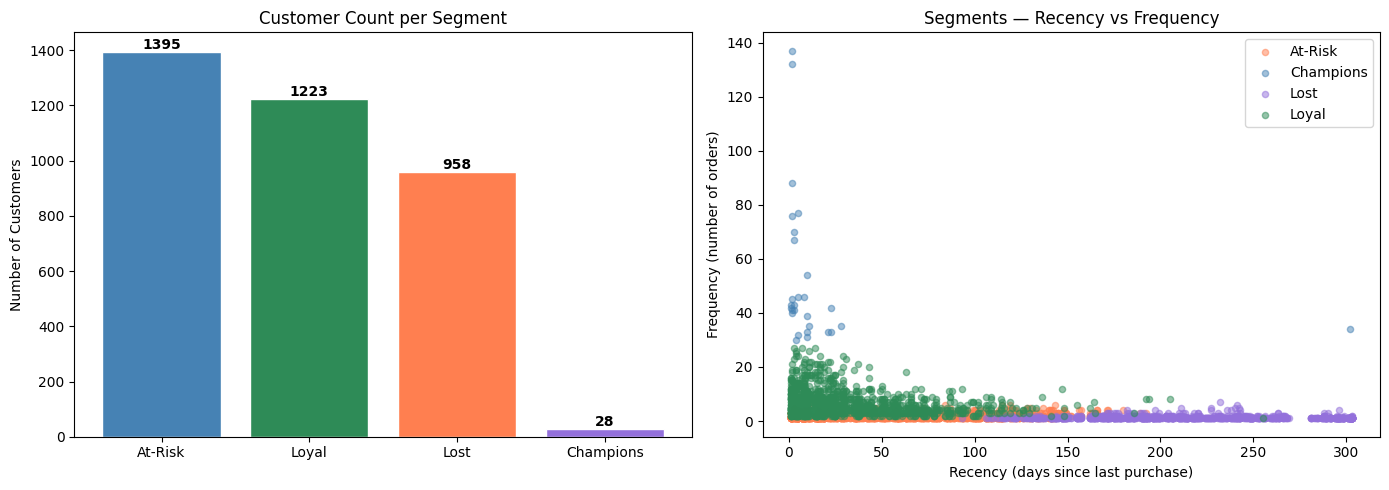

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Segment sizes
seg_counts = rfm['SegmentName'].value_counts()
colors = ['steelblue', 'seagreen', 'coral', 'mediumpurple']
axes[0].bar(seg_counts.index, seg_counts.values, color=colors, edgecolor='white')
axes[0].set_title('Customer Count per Segment')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(seg_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')
# Recency vs Frequency scatter coloured by segment
palette = {'Champions': 'steelblue', 'Loyal': 'seagreen',
           'At-Risk': 'coral', 'Lost': 'mediumpurple'}
for seg, grp in rfm.groupby('SegmentName'):
    axes[1].scatter(grp['Recency'], grp['Frequency'],
                    label=seg, alpha=0.5, s=20, color=palette[seg])
axes[1].set_title('Segments — Recency vs Frequency')
axes[1].set_xlabel('Recency (days since last purchase)')
axes[1].set_ylabel('Frequency (number of orders)')
axes[1].legend()
plt.tight_layout()
plt.savefig('../data/segments.png', dpi=150)
plt.show()

## Segmentation Business Interpretation
Four distinct customer personalities emerged from the data:

  **Champions — 28 customers (0.8%)**
  Recency: 18 days | Frequency: 52 orders | Monetary: £46,590 | Churn: 4%
  The elite. They buy constantly, spend enormously, and almost never leave.
  28 customers but disproportionate revenue impact — losing even one is significant.
  Business action: White-glove treatment. Personal outreach, early access to new
  products, exclusive loyalty rewards. These customers must never feel ignored.

  **Loyal — 1,223 customers (33.9%)**
  Recency: 33 days | Frequency: 6.45 orders | Monetary: £2,998 | Churn: 26%
  The backbone of the business. Engaged, spending well, mostly staying.
  Business action: Nurture and grow. These are tomorrow's Champions —
  reward their loyalty, upsell complementary products, keep them engaged.

  **At-Risk — 1,395 customers (38.7%)**
  Recency: 63 days | Frequency: 1.83 orders | Monetary: £605 | Churn: 55%
  The largest group and highest-priority intervention target. Mostly one-time
  or two-time buyers who haven't re-engaged. Over half will churn.
  Business action: Targeted re-engagement campaigns based on purchase history.
  A small discount or personalized recommendation could save many of these.

  **Lost — 958 customers (26.6%)**
  Recency: 215 days | Frequency: 1.25 orders | Monetary: £352 | Churn: 72%
  Haven't bought in 7 months on average. 72% have churned.
  Business action: One low-cost win-back attempt maximum —
  "We miss you" email with a small offer. Don't over-invest here.

  ## The Business Priority Order
  1. Protect Champions (28 people, outsized revenue)
  2. Intervene on At-Risk (largest group, still saveable)
  3. Grow Loyal into Champions
  4. One win-back attempt on Lost, then move on

In [14]:
rfm.to_csv('../data/rfm_segmented.csv', index=False)

print('Saved: rfm_segmented.csv')
print('Columns:', rfm.columns.tolist())
print('\nStep 5 complete. Next: Chapter 6 — Product Recommendations')

Saved: rfm_segmented.csv
Columns: ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Churn', 'Q1_Orders', 'Q2_Orders', 'Q3_Orders', 'PurchaseTrend', 'ActiveInQ3', 'AvgOrderValue', 'PurchaseSpread', 'UniqueProducts', 'LogMonetary', 'LogAvgOrderValue', 'IsOneTimeBuyer', 'AvgDaysBetweenPurchases', 'Segment', 'SegmentName']

Step 5 complete. Next: Chapter 6 — Product Recommendations
